# Facility-Level PUE Results — Exploratory Plots

Exploratory plots over `outputs/month2_pue/facility_pue.csv` (period-mean
summary) and `outputs/month2_pue/facility_pue_timeseries.csv` (full daily
series), produced by `scripts/run_pue_processing.py` (109/109 Oregon data
centers). See `docs/tasks/1.2-pue-analysis.md` for the task closeout and
`src/climate_risk_dc/climate/pue.py` for the model itself.

## Scope
- Chronic risk only: Power Usage Effectiveness (PUE) under the Lei & Masanet
  (2020) AE-variant model (airside economizer + adiabatic cooling), a generic
  "typical hyperscale" equipment spec (Table A.1 midpoints) applied uniformly
  to every facility — not facility-specific equipment.
- Three periods, matching 1.1's corrected window structure: historical
  (1985-2014), mid-century (2045-2074, primary), end-of-century (2075-2100,
  secondary), single LOCA2 GCM/member (ACCESS-CM2, r1i1p1f1), SSP585.
- Daily PUE is a **downstep from the model's validated hourly resolution** —
  approximated here by pairing Tmax+RHmin and Tmin+RHmax (typical diurnal
  anti-correlation) and averaging the two pairings; see
  `run_pue_processing.py`'s assumptions log. Treat trends as directionally
  informative, not hourly-accurate.
- No elevation adjustment (`p_atm_pa` fixed at standard atmosphere for every
  facility — no DEM in the repo yet), same caveat as the 1.1 heat notebook.

This notebook only reads the two CSVs; it does not recompute anything. Rerun
`scripts/run_pue_processing.py` first if they are missing or stale.


In [1]:
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

ROOT = Path('/home/server/pi/homes/queenl/projects/climate-risk-dc')
OUT = ROOT / 'outputs' / 'month2_pue'
SUMMARY_CSV = OUT / 'facility_pue.csv'
TIMESERIES_CSV = OUT / 'facility_pue_timeseries.csv'


## Palette and chart style

Fixed roles from the project's validated reference palette (light mode):
one categorical blue for single-series comparisons, categorical slots 1-3
(blue/orange/aqua -- the subset validated for all-pairs use, e.g. scatter
and small multiples) for the three-period comparisons, a one-hue blue ramp
for sequential/magnitude encoding, and muted ink/gridline tokens so text
never borrows a series color. See the `dataviz` skill's `references/palette.md`
for the full set and the colorblind-safety validation behind it.


In [2]:
# Reference palette (light mode) -- see dataviz skill references/palette.md
INK_PRIMARY = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRIDLINE = '#e1e0d9'
AXIS_LINE = '#c3c2b7'
SERIES_BLUE = '#2a78d6'      # categorical slot 1 -- single-series marks, historical period
SERIES_ORANGE = '#eb6834'    # categorical slot 2 -- mid-century period
SERIES_AQUA = '#1baf7a'      # categorical slot 3 -- end-of-century period

PERIOD_COLORS = {
    'historical_1985_2014': SERIES_BLUE,
    'ssp585_2045_2074': SERIES_ORANGE,
    'ssp585_2075_2100': SERIES_AQUA,
}
PERIOD_LABELS = {
    'historical_1985_2014': 'Historical (1985-2014)',
    'ssp585_2045_2074': 'Mid-century (2045-2074)',
    'ssp585_2075_2100': 'End-of-century (2075-2100)',
}
PERIOD_ORDER = ['historical_1985_2014', 'ssp585_2045_2074', 'ssp585_2075_2100']

# Sequential one-hue blue ramp, light (near-zero) -> dark (high magnitude)
SEQUENTIAL_BLUE_STEPS = [
    '#cde2fb', '#b7d3f6', '#9ec5f4', '#86b6ef', '#6da7ec', '#5598e7',
    '#3987e5', '#2a78d6', '#256abf', '#1c5cab', '#184f95', '#104281', '#0d366b',
]
SEQUENTIAL_BLUE_CMAP = LinearSegmentedColormap.from_list('sequential_blue', SEQUENTIAL_BLUE_STEPS)

plt.rcParams.update({
    'figure.dpi': 140,
    'axes.edgecolor': AXIS_LINE,
    'axes.labelcolor': INK_SECONDARY,
    'axes.titlecolor': INK_PRIMARY,
    'text.color': INK_PRIMARY,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'grid.color': GRIDLINE,
    'axes.grid': True,
    'grid.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})


## Load facility-level summary (period means)

In [3]:
if not SUMMARY_CSV.exists():
    raise FileNotFoundError(f'{SUMMARY_CSV} not found -- run scripts/run_pue_processing.py first.')

facilities = pd.read_csv(SUMMARY_CSV)
facilities['facility_label'] = facilities['facility_name'].fillna(
    'Unnamed (ID ' + facilities['facility_id'].astype(str) + ')'
)

print(f'{len(facilities)} facilities loaded')
neg_mid = int((facilities['pue_mid_century_delta'] < 0).sum())
neg_eoc = int((facilities['pue_end_of_century_delta'] < 0).sum())
print(f'Sanity: {neg_mid} negative mid-century deltas, {neg_eoc} negative end-of-century deltas '
      '(expect close to 0 under SSP585, though daily-pairing noise can make individual deltas small/negative)')
print()
print('PUE range by period:')
print(facilities[['pue_historical_1985_2014', 'pue_ssp585_2045_2074', 'pue_ssp585_2075_2100']].describe().loc[['min', 'mean', 'max']])
facilities.head()


109 facilities loaded
Sanity: 0 negative mid-century deltas, 0 negative end-of-century deltas (expect close to 0 under SSP585, though daily-pairing noise can make individual deltas small/negative)

PUE range by period:
      pue_historical_1985_2014  pue_ssp585_2045_2074  pue_ssp585_2075_2100
min                   1.119670              1.119939              1.120226
mean                  1.119882              1.120870              1.122500
max                   1.119995              1.121449              1.124288


,facility_id,facility_name,facility_lon,facility_lat,pue_historical_1985_2014,pue_ssp585_2045_2074,pue_ssp585_2075_2100,pue_mid_century_delta,pue_end_of_century_delta,facility_label
0,19988712,Meta Prineville Datacenter,-120.886382,44.298443,1.119813,1.120124,1.120310,0.000311,0.000498,Meta Prineville Datacenter
1,19993392,Apple Prineville Datacenter,-120.865883,44.284558,1.119857,1.120168,1.120379,0.000311,0.000521,Apple Prineville Datacenter
2,52059176,NTT RagingWire Data Center,-122.937393,45.549584,1.119734,1.120611,1.123967,0.000877,0.004233,NTT RagingWire Data Center
3,231769626,Google Data Center The Dalles Oregon,-121.201302,45.632048,1.119911,1.120551,1.121305,0.000640,0.001394,Google Data Center The Dalles Oregon
4,321385147,NaN,-120.887261,44.295883,1.119813,1.120124,1.120310,0.000311,0.000498,Unnamed (ID 321385147)


## Load full daily time series

3,423,690 rows (109 facilities x 3 periods x ~10,450-10,957 days each) --
loading only the columns needed for these plots keeps this fast (a few
seconds rather than tens).


In [4]:
if not TIMESERIES_CSV.exists():
    raise FileNotFoundError(f'{TIMESERIES_CSV} not found -- run scripts/run_pue_processing.py first.')

usecols = ['facility_id', 'facility_name', 'period', 'date', 'tasmax_c', 'hursmin_pct',
           'pue_hot_pairing', 'pue_cool_pairing', 'pue_daily']
ts = pd.read_csv(TIMESERIES_CSV, usecols=usecols, parse_dates=['date'])
ts['period'] = pd.Categorical(ts['period'], categories=PERIOD_ORDER, ordered=True)
ts['month'] = ts['date'].dt.month
ts['doy'] = ts['date'].dt.dayofyear

print(f'{len(ts):,} daily facility-period rows loaded')
print(ts.groupby('period', observed=True)['date'].agg(['min', 'max', 'count']))


3,423,690 daily facility-period rows loaded


                                     min                 max    count
period                                                               
historical_1985_2014 1985-01-01 12:00:00 2014-12-31 12:00:00  1194313
ssp585_2045_2074     2045-01-01 12:00:00 2074-12-31 12:00:00  1194313
ssp585_2075_2100     2075-01-01 12:00:00 2100-12-31 12:00:00  1035064


## Fleet-wide daily time series, by period

Daily PUE averaged across all 109 facilities (bold line), with the
facility-to-facility spread shown as a shaded band (min-max across
facilities that day), plus a 30-day rolling mean to make the seasonal
signal legible against day-to-day pairing noise. One panel per period since
the three periods don't share a continuous calendar axis; a shared y-axis
makes the panels visually comparable.


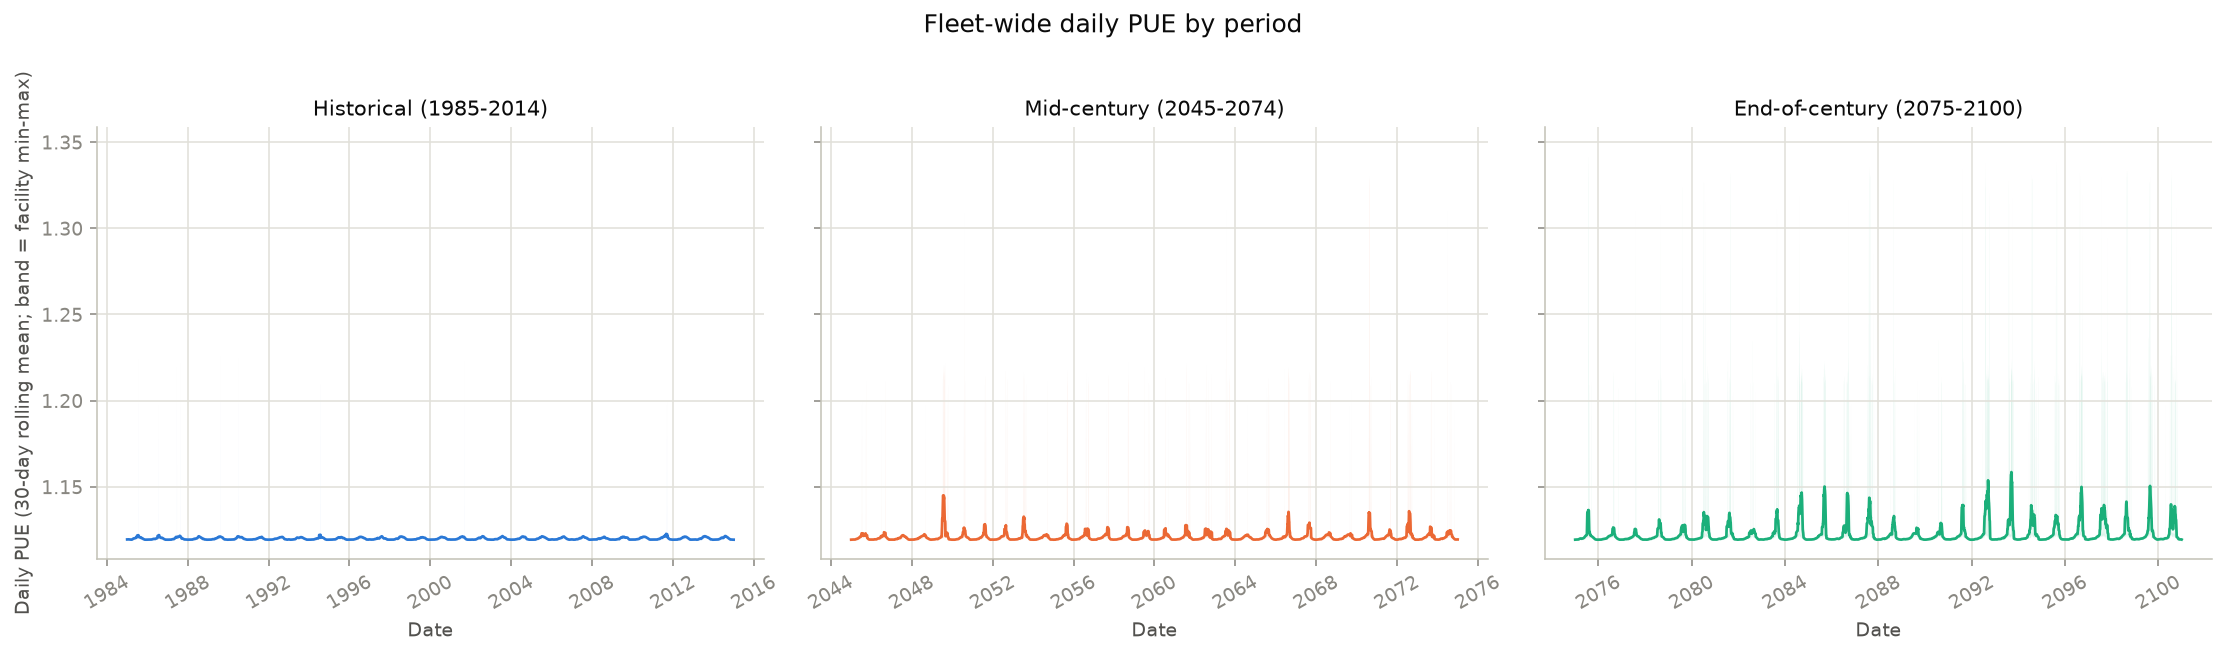

In [5]:
fleet_daily = (
    ts.groupby(['period', 'date'], observed=True)['pue_daily']
    .agg(['mean', 'min', 'max'])
    .reset_index()
    .sort_values(['period', 'date'])
)

y_lo = fleet_daily['min'].min()
y_hi = fleet_daily['max'].max()
y_pad = (y_hi - y_lo) * 0.05

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, period in zip(axes, PERIOD_ORDER):
    sub = fleet_daily[fleet_daily['period'] == period]
    color = PERIOD_COLORS[period]
    ax.fill_between(sub['date'], sub['min'], sub['max'], color=color, alpha=0.15, linewidth=0, zorder=1)
    rolling = sub['mean'].rolling(30, center=True, min_periods=10).mean()
    ax.plot(sub['date'], rolling, color=color, linewidth=1.4, zorder=2)
    ax.set_title(PERIOD_LABELS[period], color=INK_PRIMARY, fontsize=11)
    ax.set_xlabel('Date')
    ax.tick_params(axis='x', rotation=30)

axes[0].set_ylabel('Daily PUE (30-day rolling mean; band = facility min-max)')
axes[0].set_ylim(y_lo - y_pad, y_hi + y_pad)
fig.suptitle('Fleet-wide daily PUE by period', y=1.03, fontsize=13, color=INK_PRIMARY)
fig.tight_layout()
plt.show()


## Seasonal cycle (monthly climatology), historical vs. projected futures

Mean PUE by calendar month, averaged across all facilities and all years in
each period -- three periods on one axis (one line per period, categorical
palette slots 1-3, all validated for simultaneous on-screen use). Summer
months carry the largest gap: that's when mechanical cooling is most likely
to be needed, so it's where the model is most sensitive to projected warming.


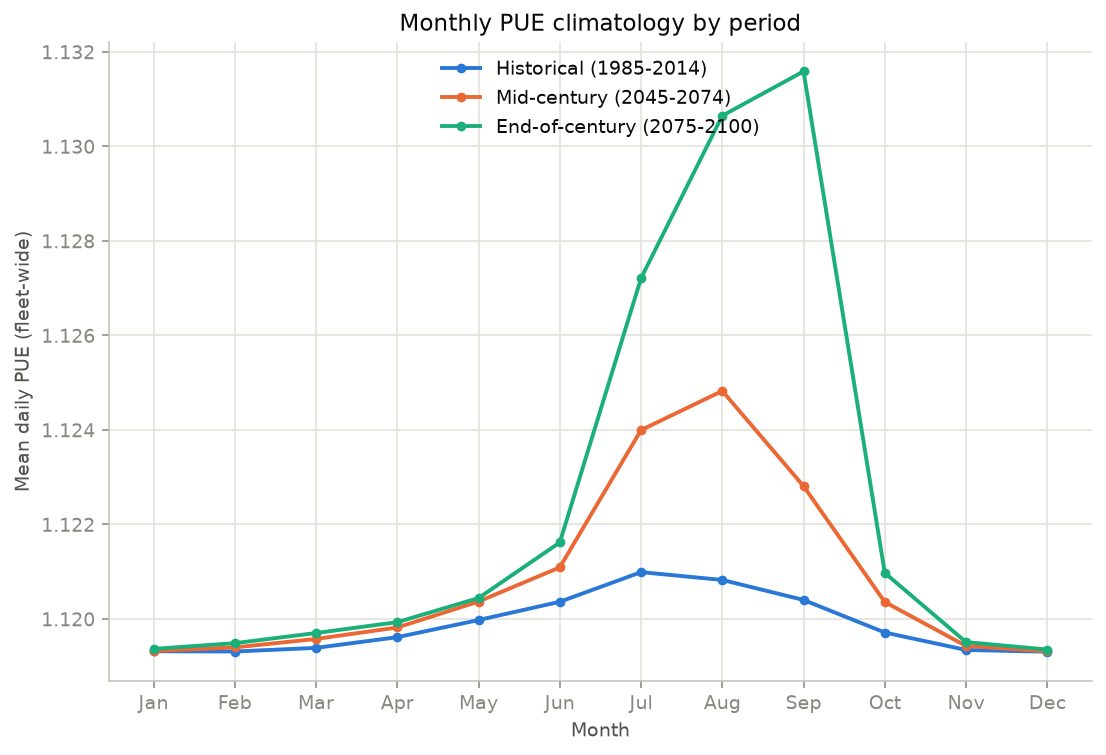

In [6]:
monthly = (
    ts.groupby(['period', 'month'], observed=True)['pue_daily']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5.5))
for period in PERIOD_ORDER:
    sub = monthly[monthly['period'] == period].sort_values('month')
    ax.plot(sub['month'], sub['pue_daily'], color=PERIOD_COLORS[period], linewidth=2,
            marker='o', markersize=4, label=PERIOD_LABELS[period])

ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.set_xlabel('Month')
ax.set_ylabel('Mean daily PUE (fleet-wide)')
ax.set_title('Monthly PUE climatology by period', color=INK_PRIMARY, fontsize=12)
ax.legend(frameon=False, loc='upper center')
fig.tight_layout()
plt.show()


## Historical vs. future, per facility

One point per facility, historical period-mean PUE on x, projected-future
period-mean PUE on y -- mid-century and end-of-century as two panels sharing
axis limits. A single series (facility) plotted against itself across two
time windows, so one categorical color per panel and a 1:1 reference line
rather than a legend -- points above the dashed line got less efficient
(higher PUE) under SSP585.


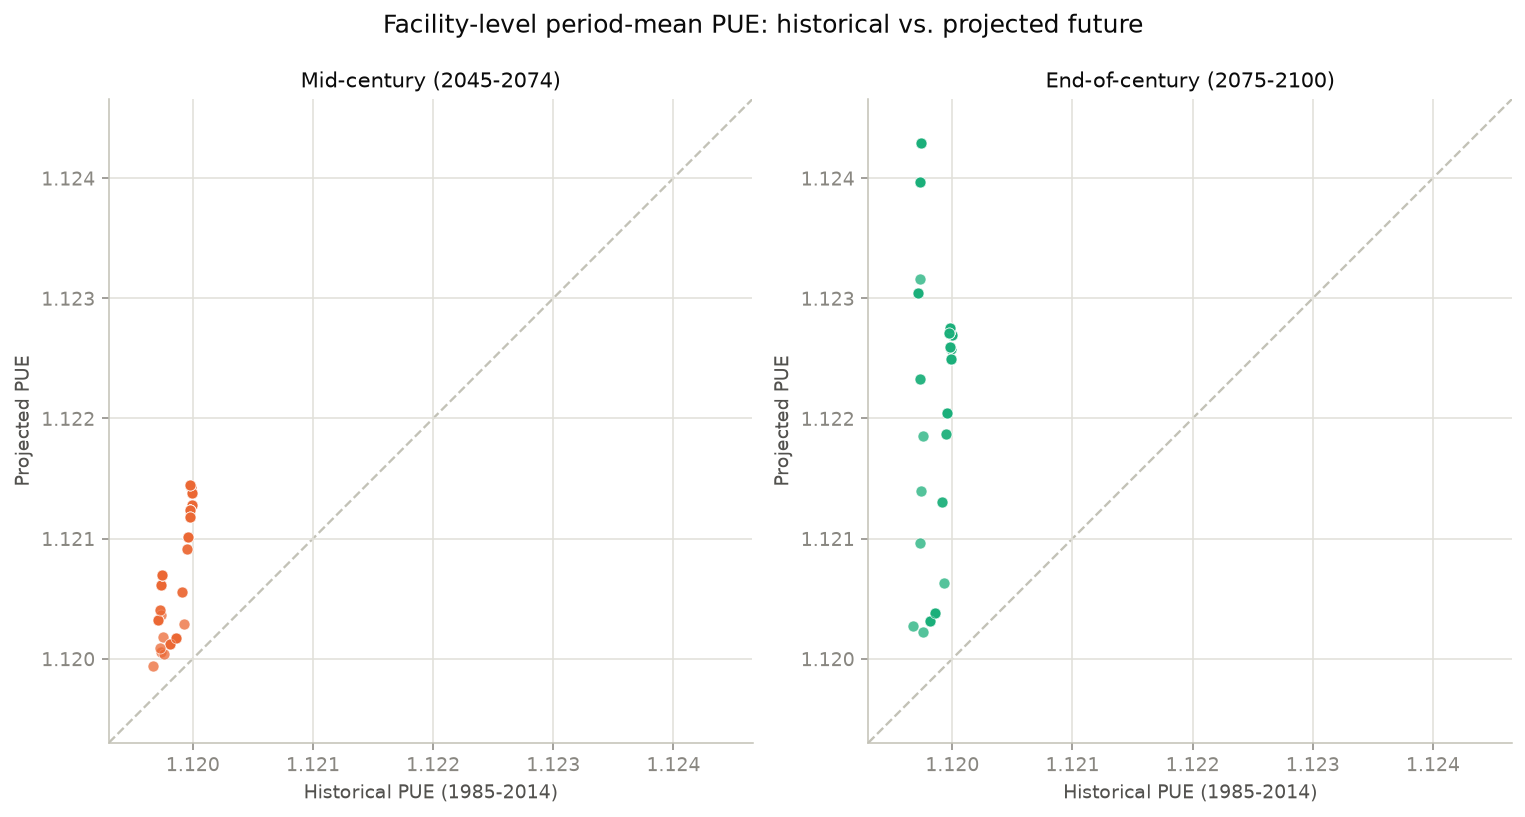

In [7]:
future_panels = [
    ('pue_ssp585_2045_2074', SERIES_ORANGE, 'Mid-century (2045-2074)'),
    ('pue_ssp585_2075_2100', SERIES_AQUA, 'End-of-century (2075-2100)'),
]

x_all = facilities['pue_historical_1985_2014'].to_numpy()
y_all = np.concatenate([facilities[col].to_numpy() for col, _, _ in future_panels])
lo, hi = min(x_all.min(), y_all.min()), max(x_all.max(), y_all.max())
pad = (hi - lo) * 0.08

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
for ax, (fut_col, color, title) in zip(axes, future_panels):
    x = facilities['pue_historical_1985_2014'].to_numpy()
    y = facilities[fut_col].to_numpy()
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], linestyle='--', linewidth=1.2, color=AXIS_LINE, zorder=1)
    ax.scatter(x, y, s=32, color=color, alpha=0.75, edgecolor='white', linewidth=0.4, zorder=2)
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_xlabel('Historical PUE (1985-2014)')
    ax.set_ylabel('Projected PUE')
    ax.set_title(title, color=INK_PRIMARY, fontsize=11)
    ax.set_aspect('equal', adjustable='box')

fig.suptitle('Facility-level period-mean PUE: historical vs. projected future', y=1.02, fontsize=13, color=INK_PRIMARY)
fig.tight_layout()
plt.show()


## Distribution of projected change (delta = future period-mean minus historical)

Single-hue histograms (magnitude, not polarity -- deltas are expected
non-negative per the sanity check above). Note the scale: PUE deltas are two
to three orders of magnitude smaller than the heat-index deltas in the 1.1
notebook -- this AE model spends most non-summer days in a free-cooling
regime where PUE is essentially flat near its floor, so a warming climate
mostly lengthens the (already small) mechanical-cooling season rather than
moving PUE much on an annual-mean basis. Treat these as small-but-real
signals, not noise.


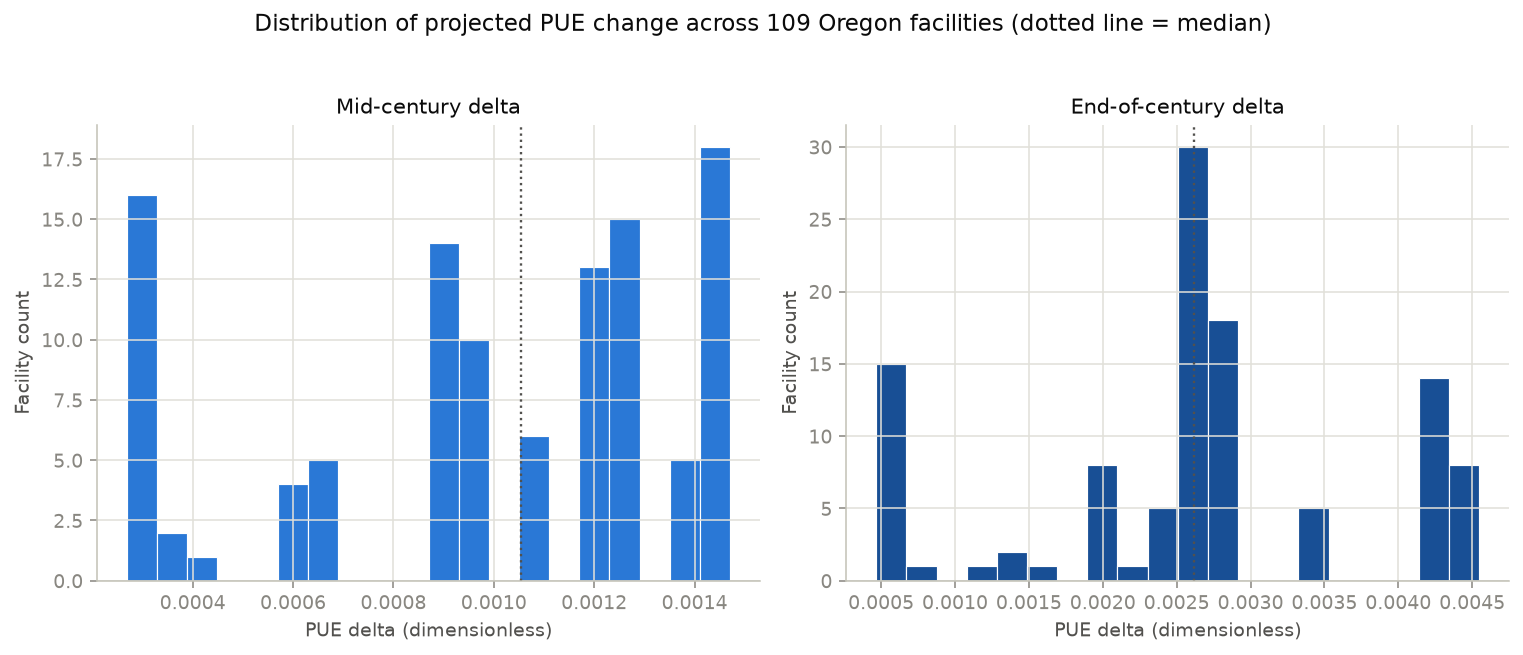

In [8]:
delta_panels = [
    ('pue_mid_century_delta', SEQUENTIAL_BLUE_STEPS[7], 'Mid-century delta'),
    ('pue_end_of_century_delta', SEQUENTIAL_BLUE_STEPS[10], 'End-of-century delta'),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (col, color, title) in zip(axes, delta_panels):
    values = facilities[col]
    ax.hist(values, bins=20, color=color, edgecolor='white', linewidth=0.6)
    ax.axvline(values.median(), color=INK_SECONDARY, linestyle=':', linewidth=1.2)
    ax.set_title(title, color=INK_PRIMARY, fontsize=11)
    ax.set_xlabel('PUE delta (dimensionless)')
    ax.set_ylabel('Facility count')

fig.suptitle('Distribution of projected PUE change across 109 Oregon facilities (dotted line = median)', y=1.03, fontsize=12, color=INK_PRIMARY)
fig.tight_layout()
plt.show()


## Facilities with the largest projected increase

Top 15 by end-of-century PUE delta. Ordered ranking, single hue (magnitude,
not identity), with direct end-labels since there are only 15 bars.


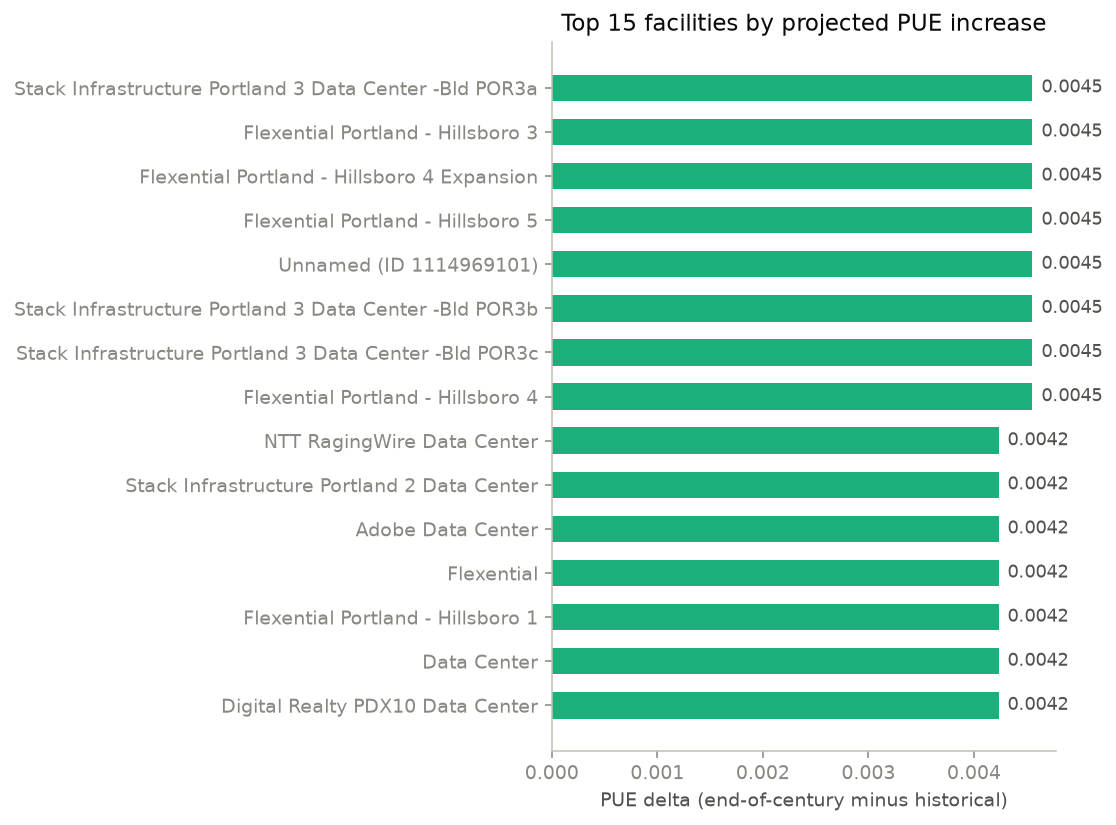

In [9]:
top15 = facilities.nlargest(15, 'pue_end_of_century_delta').sort_values('pue_end_of_century_delta')

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(top15['facility_label'], top15['pue_end_of_century_delta'], color=SERIES_AQUA, height=0.6)
for bar, value in zip(bars, top15['pue_end_of_century_delta']):
    ax.text(bar.get_width() + bar.get_width() * 0.02, bar.get_y() + bar.get_height() / 2, f'{value:.4f}',
            va='center', ha='left', fontsize=9, color=INK_SECONDARY)

ax.set_xlabel('PUE delta (end-of-century minus historical)')
ax.set_title('Top 15 facilities by projected PUE increase', color=INK_PRIMARY, fontsize=12)
ax.grid(axis='x')
ax.grid(axis='y', visible=False)
fig.tight_layout()
plt.show()


## PUE response to outdoor temperature

The daytime pairing (`pue_hot_pairing`, driven by Tmax+RHmin) for one
representative facility's historical period, plotted against Tmax --
this is the model's characteristic curve: flat near the airside-economizer
floor while free cooling covers the load, then rising once outdoor
conditions push the model into mechanical cooling. Useful as a model sanity
check as well as an explanation for why annual-mean deltas are small: most
Oregon days sit on the flat part of this curve.


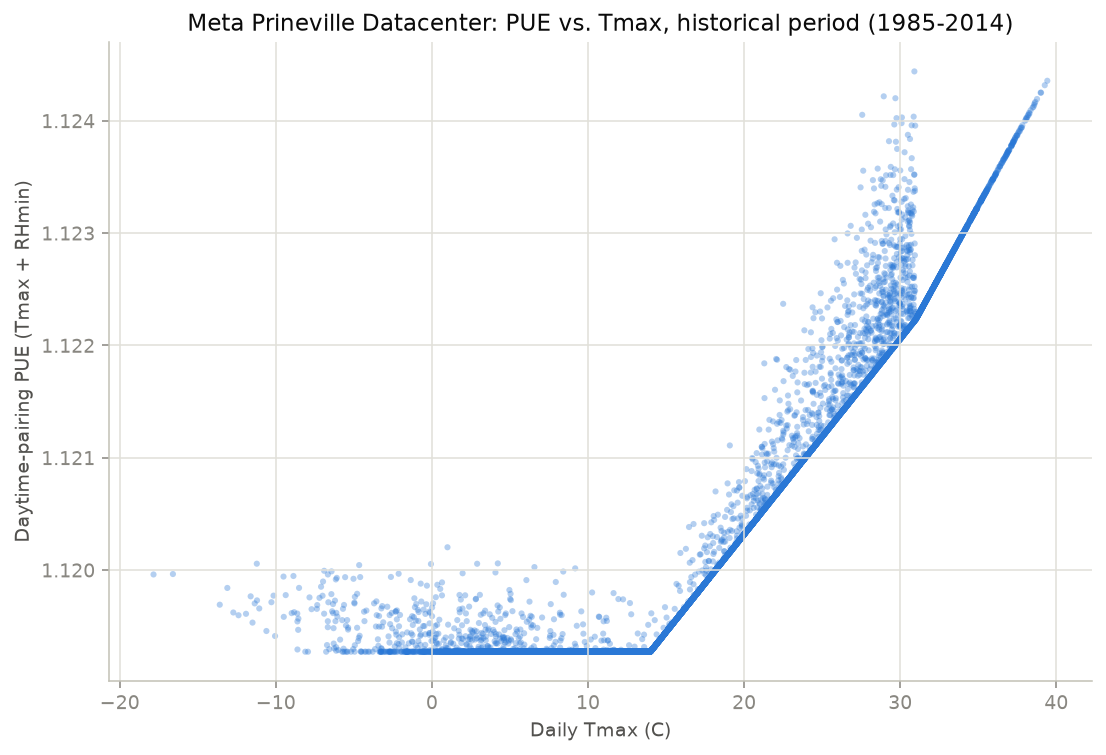

In [10]:
EXAMPLE_FACILITY_ID = 19988712  # Meta Prineville Datacenter

example = ts[(ts['facility_id'] == EXAMPLE_FACILITY_ID) & (ts['period'] == 'historical_1985_2014')]
example_name = example['facility_name'].iloc[0]

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(example['tasmax_c'], example['pue_hot_pairing'], s=10, color=SERIES_BLUE, alpha=0.35, edgecolor='none')
ax.set_xlabel('Daily Tmax (C)')
ax.set_ylabel('Daytime-pairing PUE (Tmax + RHmin)')
ax.set_title(f'{example_name}: PUE vs. Tmax, historical period (1985-2014)', color=INK_PRIMARY, fontsize=12)
fig.tight_layout()
plt.show()


## Geographic pattern

Facility locations colored by end-of-century PUE delta (sequential blue
ramp = magnitude; a colorbar substitutes for a legend since color here is
continuous, not categorical). Same Oregon/PNW extent as the 1.1 heat
notebook's geographic panel.


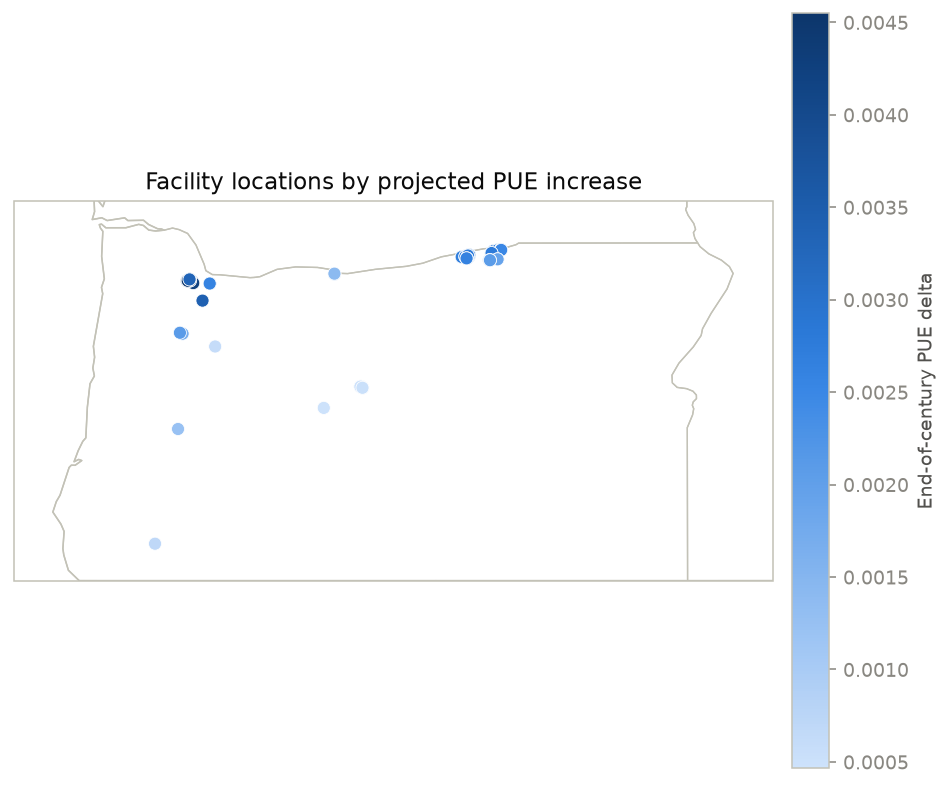

In [11]:
projection = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(7, 8), subplot_kw={'projection': projection})
ax.set_extent([-125, -116, 42, 46.5], crs=projection)
ax.add_feature(cfeature.STATES.with_scale('50m'), edgecolor=AXIS_LINE, linewidth=0.7, zorder=1)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), edgecolor=INK_SECONDARY, linewidth=0.8, zorder=1)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), edgecolor=AXIS_LINE, linewidth=0.8, zorder=1)

sc = ax.scatter(
    facilities['facility_lon'], facilities['facility_lat'],
    c=facilities['pue_end_of_century_delta'], cmap=SEQUENTIAL_BLUE_CMAP,
    s=45, edgecolor='white', linewidth=0.4, zorder=2,
    transform=projection,
)
cbar = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('End-of-century PUE delta', color=INK_SECONDARY)
cbar.ax.tick_params(color=INK_MUTED, labelcolor=INK_MUTED)

ax.set_title('Facility locations by projected PUE increase', color=INK_PRIMARY, fontsize=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(False)
fig.tight_layout()
plt.show()


## Caveats

- Single-GCM/member (ACCESS-CM2, r1i1p1f1) -- not an ensemble spread; treat
  magnitudes as one plausible trajectory, not a confidence interval.
- Generic equipment spec for every facility (Table A.1 midpoints of the
  Lei & Masanet AE model) -- not any specific Oregon facility's real cooling
  system, so absolute PUE values (~1.12) should not be read as a claim about
  any named facility's actual efficiency.
- Daily Tmax+RHmin / Tmin+RHmax pairing is an explicit approximation for a
  model validated against hourly data -- see `run_pue_processing.py`'s
  assumptions log. Directionally informative, not hourly-accurate.
- No elevation adjustment (`p_atm_pa` fixed at standard atmosphere) -- no DEM
  in the repo yet.
- PUE deltas are small in absolute terms (max ~0.0045 end-of-century) because
  the AE model spends most Oregon days in a free-cooling regime; don't
  over-interpret facility rankings built on deltas this size as more than
  directional.
- `facility_label` falls back to `Unnamed (ID ...)` for the handful of
  Prineville/PDX parcels with a null name in the source atlas.
